## Wave Adder

## Lets import stuff and define some helpers

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

from constants import DEFAULT_SAMPLE_RATE
from engine import SineOscillator, SquareOscillator, TriangleOscillator, WaveAdder
from utils import note_to_frequency, save_wave


# helper function to get frequency plot data
def fft_xy(wave, fslice=slice(0, 100), sample_rate=DEFAULT_SAMPLE_RATE):
    fd = np.fft.fft(wave)
    fd_mag = np.abs(fd)
    x = np.linspace(0, sample_rate, len(wave))
    y = fd_mag * 2 / sample_rate
    return x[fslice], y[fslice]


def plot_leftright(left, right, sr=DEFAULT_SAMPLE_RATE):
    duration = len(left) / sr
    time = np.linspace(0, duration, len(left))

    _, ax = plt.subplots(1, 2, figsize=(25, 6))
    ax[0].plot(time, left)
    ax[0].set_title("Left Channel")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Amplitude")

    ax[1].plot(time, right)
    ax[1].set_title("Right Channel")
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


# Set up plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10

## Adding two sine waves

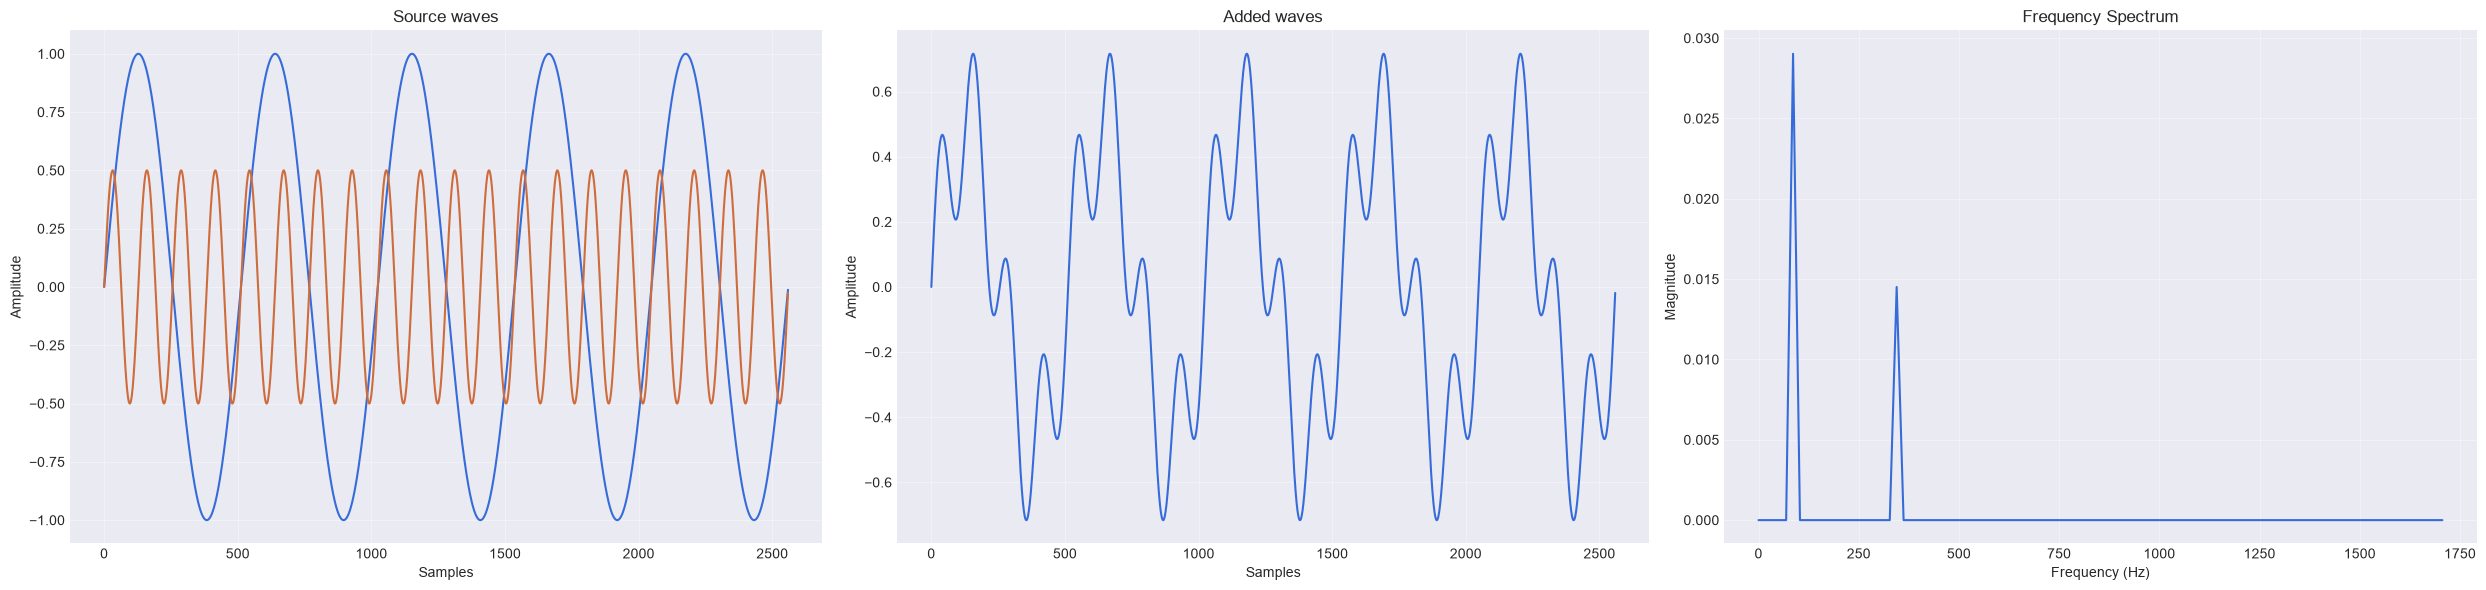

In [2]:
sr = 512
osc1 = SineOscillator(frequency=1, amplitude=1, phase=0, sample_rate=sr)
osc2 = SineOscillator(frequency=4, amplitude=0.5, phase=0, sample_rate=sr)
adder = WaveAdder(osc1, osc2)

num_samples = sr * 5
source1 = osc1.get_samples(num_samples)
source2 = osc2.get_samples(num_samples)
summation = adder.get_samples(num_samples)
fft_x, fft_y = fft_xy(summation)

_, ax = plt.subplots(1, 3, figsize=(25, 6))
ax[0].plot(source1)
ax[0].plot(source2)
ax[0].set_title("Source waves")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

ax[1].plot(summation)
ax[1].set_title("Added waves")
ax[1].set_xlabel("Samples")
ax[1].set_ylabel("Amplitude")

ax[2].plot(fft_x, fft_y)
ax[2].set_title("Frequency Spectrum")
ax[2].set_xlabel("Frequency (Hz)")
ax[2].set_ylabel("Magnitude")

plt.tight_layout()
plt.show()

## Adding sine and square waves

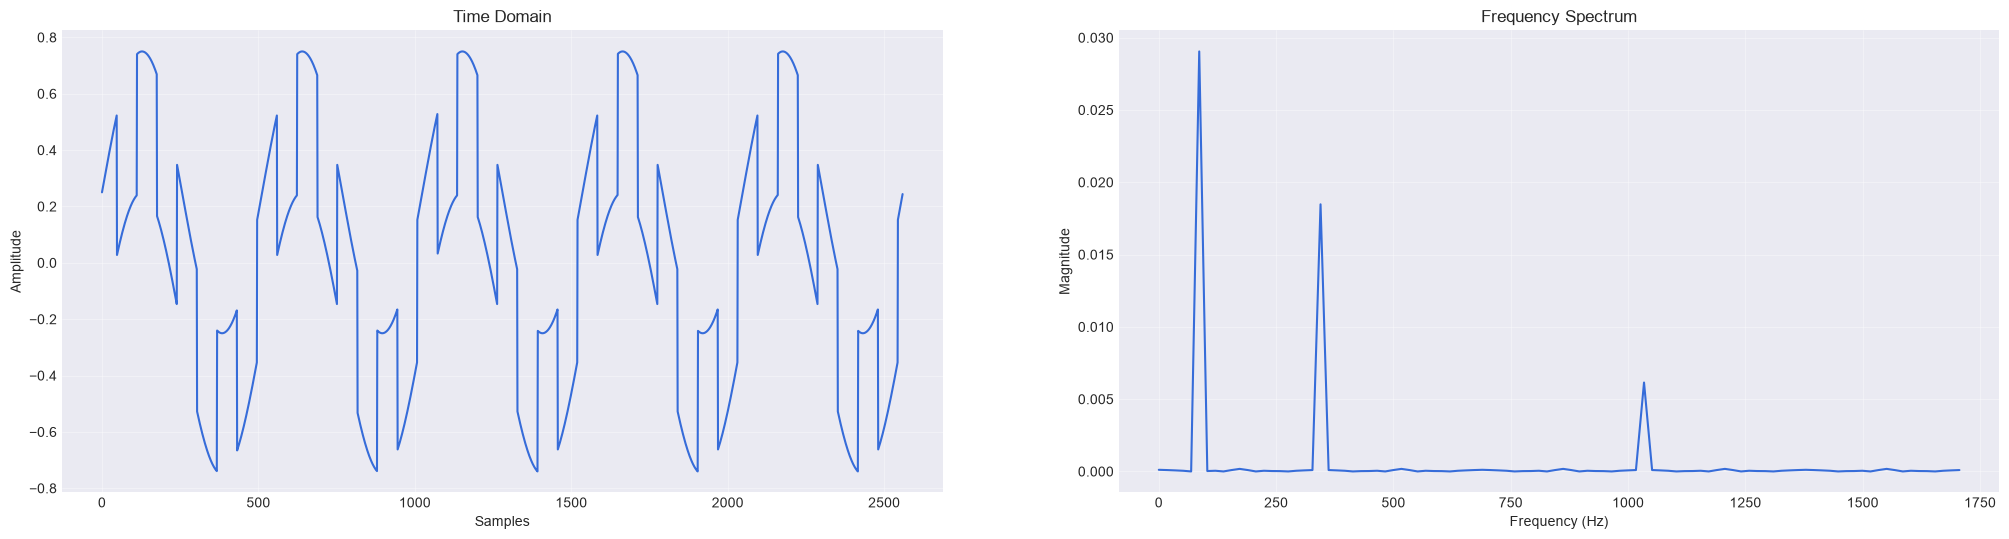

In [7]:
osc1 = SineOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
osc2 = SquareOscillator(frequency=4, amplitude=0.5, phase=45, sample_rate=512)
adder = WaveAdder(osc1, osc2)

samples_adder = adder.get_samples(n=512 * 5)
fft_x, fft_y = fft_xy(samples_adder)

_, ax = plt.subplots(1, 2, figsize=(25, 6))
ax[0].plot(samples_adder)
ax[0].set_title("Time Domain")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

ax[1].plot(fft_x, fft_y)
ax[1].set_title("Frequency Spectrum")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude")
plt.show()

## Creating a complex waveform with multiple oscillators

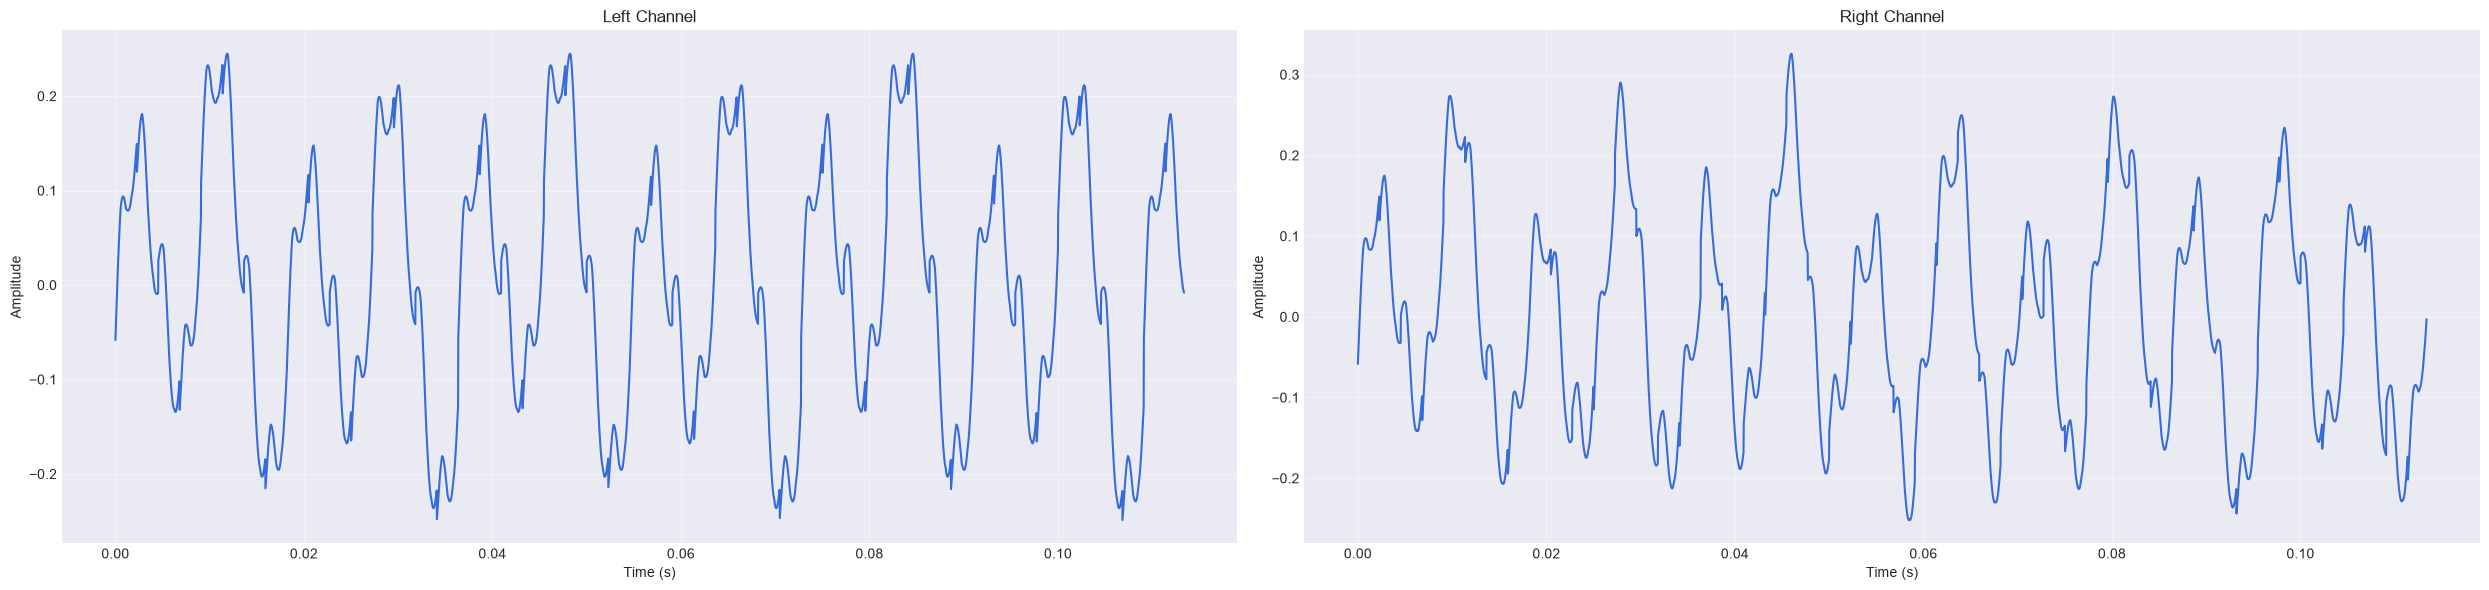

In [4]:
duration = 10  # time in seconds
sr = DEFAULT_SAMPLE_RATE
num_samples = int(duration * sr)
time = np.linspace(0, duration, num_samples)

osc = WaveAdder(
    SquareOscillator(27.5, amplitude=0.1),
    TriangleOscillator(55, amplitude=0.5),
    SineOscillator(110),
    SquareOscillator(220, amplitude=0.1),
    SineOscillator(440, amplitude=0.3),
    TriangleOscillator(880, amplitude=0.05),
)

osc2 = WaveAdder(
    SquareOscillator(27.5, amplitude=0.1),
    TriangleOscillator(55, amplitude=0.5),
    SineOscillator(115),
    SquareOscillator(220, amplitude=0.1),
    SineOscillator(440, amplitude=0.3),
    TriangleOscillator(880, amplitude=0.05),
)

left = osc.get_samples(num_samples)
right = osc2.get_samples(num_samples)

samples_to_plot = 5000
plot_leftright(left[:samples_to_plot], right[:samples_to_plot], sr)

save_wave(left, audio_right=right, filename="ot_vibes.wav")
display(Audio(data="ot_vibes.wav", rate=sr))

## A Min 6

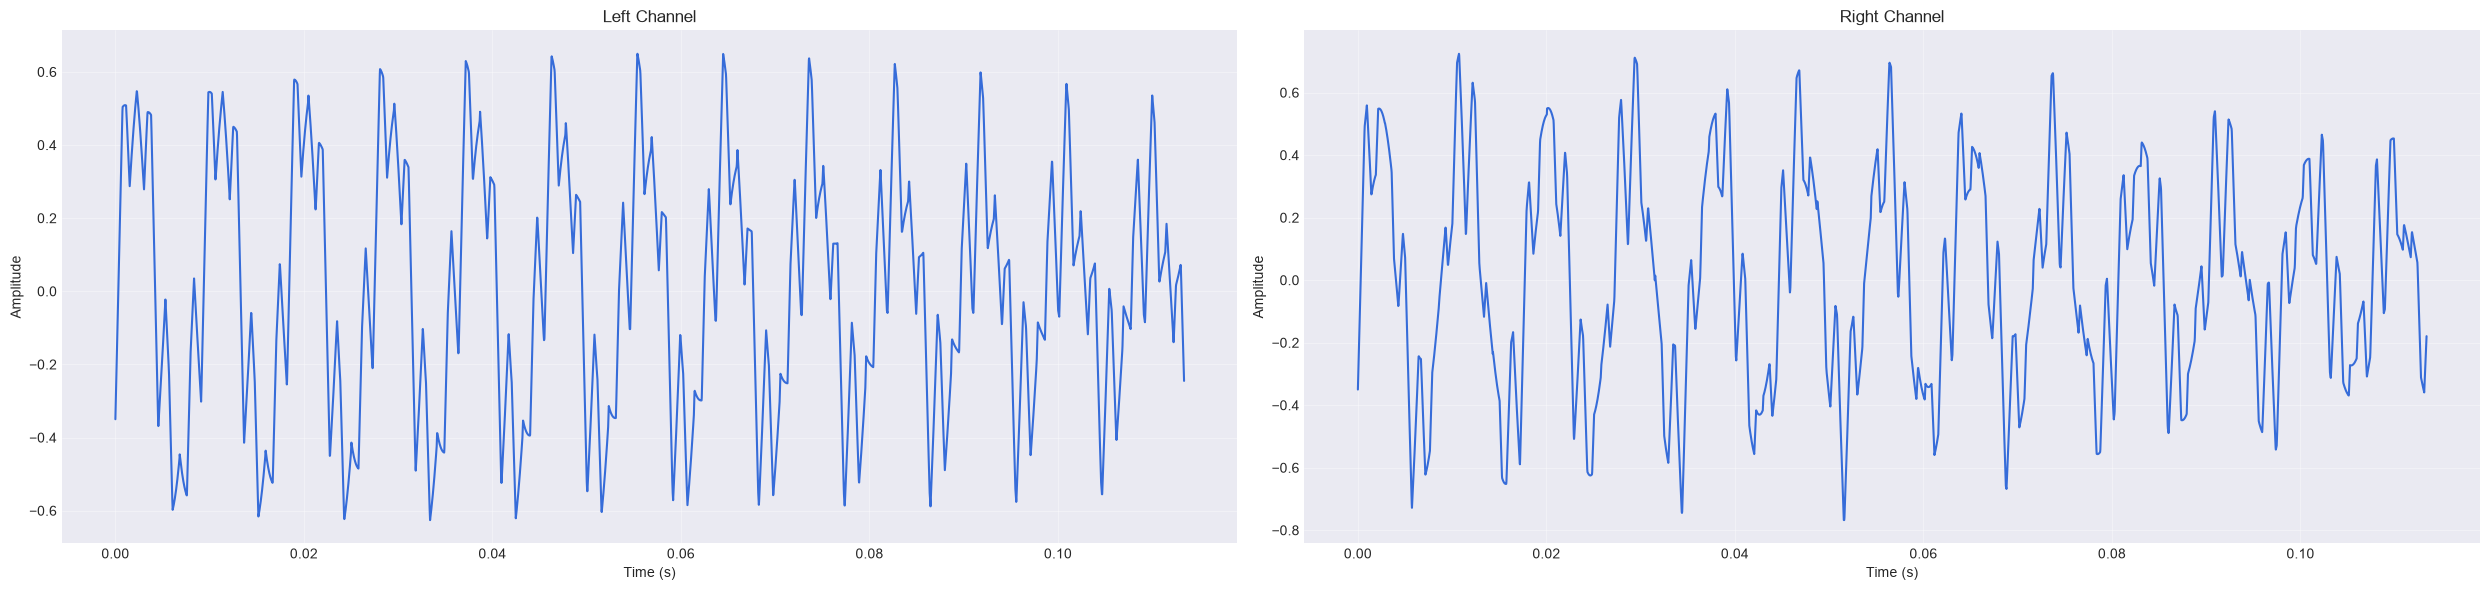

In [5]:
osc = WaveAdder(
    SineOscillator(note_to_frequency("A2")),
    SineOscillator(note_to_frequency("A2") + 3),
    TriangleOscillator(note_to_frequency("A4"), amplitude=0.6),
    TriangleOscillator(note_to_frequency("E5"), amplitude=0.8),
)

osc2 = WaveAdder(
    SineOscillator(note_to_frequency("A2")),
    SineOscillator(note_to_frequency("A2") + 3),
    TriangleOscillator(note_to_frequency("C5"), amplitude=0.8),
    TriangleOscillator(note_to_frequency("F5"), amplitude=0.6),
)

duration = 10  # time in seconds
sr = DEFAULT_SAMPLE_RATE
num_samples = int(duration * sr)

left = osc.get_samples(num_samples)
right = osc2.get_samples(num_samples)

samples_to_plot = 5000
plot_leftright(left[:samples_to_plot], right[:samples_to_plot], sr)
save_wave(left, audio_right=right, filename="ot_vibes.wav")
display(Audio(data="ot_vibes.wav", rate=sr))

## C Maj 7

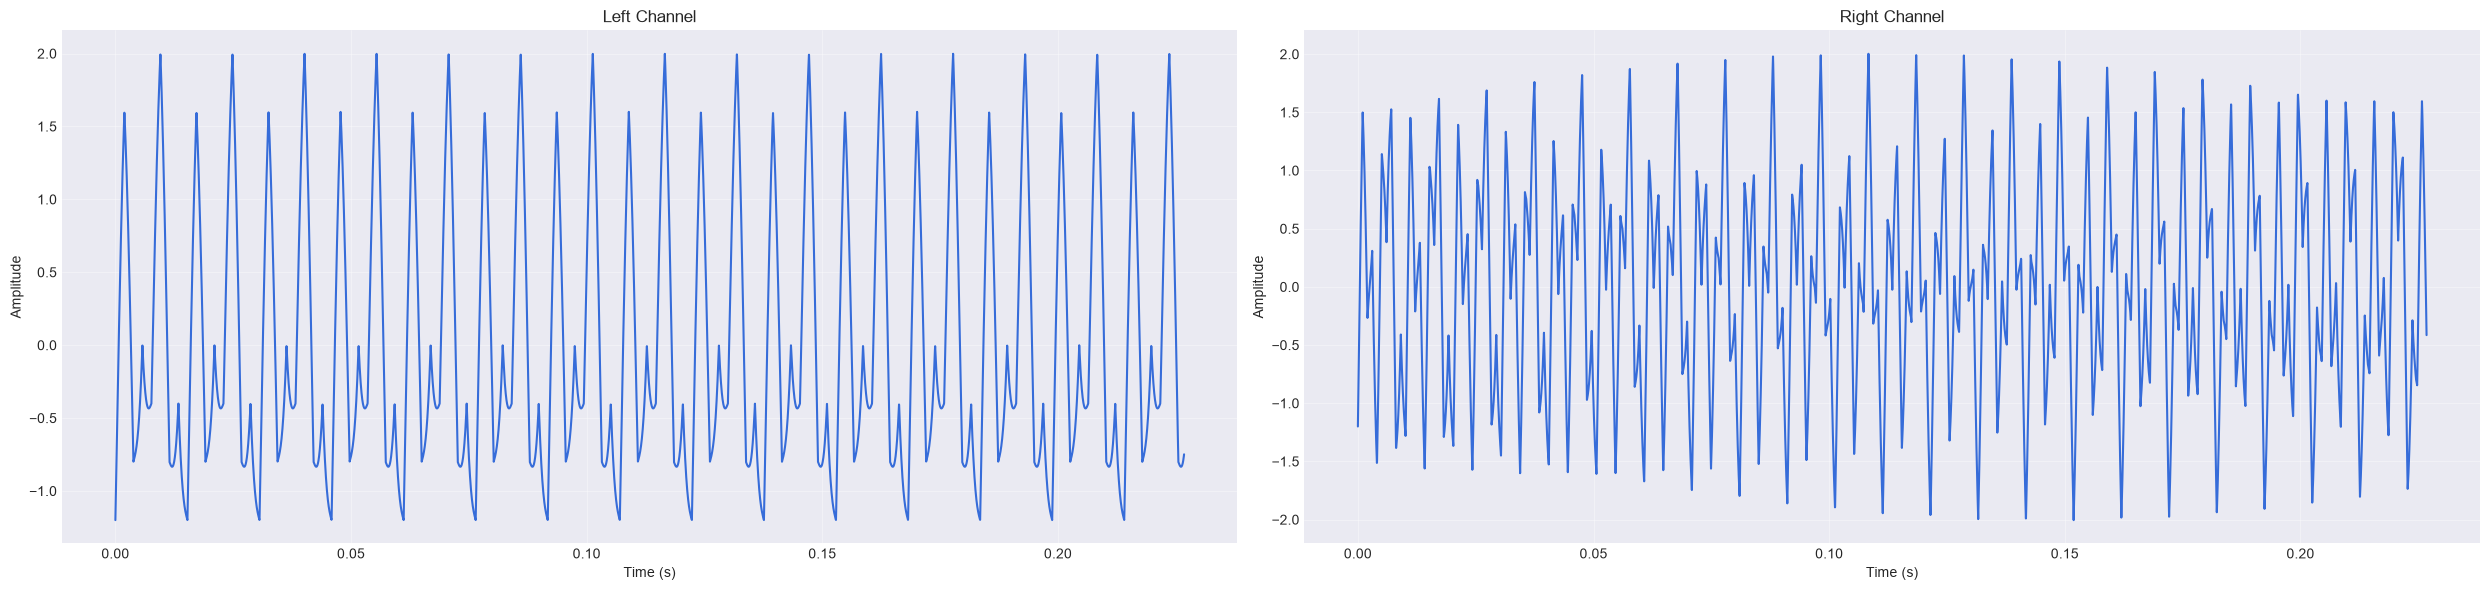

In [6]:
def get_seq(osc, notes=("C4", "E4", "G4"), note_lens=(0.5, 0.5, 0.5)):
    samples = []
    for note, note_len in zip(notes, note_lens, strict=False):
        osc.frequency = note_to_frequency(note)
        number_samples = int(DEFAULT_SAMPLE_RATE * note_len)
        samples = np.concatenate([samples, osc.get_samples(number_samples)])
    return samples


num_repetitions = 10
s1 = ["C4", "E4", "G4", "B4"] * num_repetitions
l1 = [0.25, 0.25, 0.25, 0.25] * num_repetitions

s2 = ["C3", "E3", "G3"] * num_repetitions
l2 = [0.333334, 0.333334, 0.333334] * num_repetitions

s3 = ["C2", "G2"] * num_repetitions
l3 = [0.5, 0.5] * num_repetitions

wavl = (
    np.array(get_seq(TriangleOscillator(amplitude=0.8), notes=s1, note_lens=l1))
    + np.array(get_seq(SineOscillator(), notes=s2, note_lens=l2))
    + np.array(get_seq(TriangleOscillator(amplitude=0.4), notes=s3, note_lens=l3))
)

wavr = (
    np.array(get_seq(TriangleOscillator(amplitude=0.8), notes=s1[::-1], note_lens=l1))
    + np.array(get_seq(SineOscillator(), notes=s2[::-1], note_lens=l2))
    + np.array(get_seq(TriangleOscillator(amplitude=0.4), notes=s3[::-1], note_lens=l3))
)

samples_to_plot = 10000
plot_leftright(wavl[:samples_to_plot], wavr[:samples_to_plot], DEFAULT_SAMPLE_RATE)

save_wave(wavl, wavr, sample_rate=DEFAULT_SAMPLE_RATE, filename="cmaj7.wav")
display(Audio(data="cmaj7.wav", rate=sr))